In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# U-Net model class
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        
        self.enc_conv1 = self.conv_block(in_channels, 64)
        self.enc_conv2 = self.conv_block(64, 128)
        self.enc_conv3 = self.conv_block(128, 256)
        self.enc_conv4 = self.conv_block(256, 512)
        
        self.bottleneck = self.conv_block(512, 1024)

        self.up_conv4 = self.up_conv(1024, 512)
        self.dec_conv4 = self.conv_block(1024, 512)
        
        self.up_conv3 = self.up_conv(512, 256)
        self.dec_conv3 = self.conv_block(512, 256)
        
        self.up_conv2 = self.up_conv(256, 128)
        self.dec_conv2 = self.conv_block(256, 128)
        
        self.up_conv1 = self.up_conv(128, 64)
        self.dec_conv1 = self.conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def up_conv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.enc_conv1(x)
        enc2 = self.enc_conv2(F.max_pool2d(enc1, (2, 2)))
        enc3 = self.enc_conv3(F.max_pool2d(enc2, (2, 2)))
        enc4 = self.enc_conv4(F.max_pool2d(enc3, (2, 2)))

        bottleneck = self.bottleneck(F.max_pool2d(enc4, (2, 2)))

        dec4 = self.up_conv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.dec_conv4(dec4)
        
        dec3 = self.up_conv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec_conv3(dec3)
        
        dec2 = self.up_conv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec_conv2(dec2)
        
        dec1 = self.up_conv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec_conv1(dec1)
        
        return self.final_conv(dec1)

# Dataset class
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_names = os.listdir(image_dir)
        
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        image = Image.open(os.path.join(self.image_dir, img_name))
        mask = Image.open(os.path.join(self.mask_dir, img_name)).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            mask = transforms.Resize((176, 320))(mask)
            mask = np.array(mask)
            mask = torch.tensor(self.rgb_to_class(mask), dtype=torch.long)
        
        return image, mask

    def rgb_to_class(self, mask):
        colormap = {
            (0, 0, 0): 0,         
            (255, 0, 0): 1,       
            (255, 255, 0): 2,   
            (0, 255, 0): 3,    
            (0, 0, 255): 4,   
            (255, 255, 255): 5, 
            (128, 0, 128): 6,     
            (173, 216, 230): 7, 
        }
        mask_class = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.int64)
        for rgb, class_idx in colormap.items():
            mask_class[(mask == rgb).all(axis=-1)] = class_idx
        return mask_class

# Training function
def train_model(model, dataloader, criterion, optimizer, num_epochs=25, device='cuda'):
    model = model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, masks in dataloader:
            inputs = inputs.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(dataloader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')
    
    return model

# Prediction function
def predict_and_show(model, image_path, transform, device='cuda'):
    image = Image.open(image_path)
    input_image = transform(image).unsqueeze(0).to(device)
    
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        output = model(input_image)
    
    pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    
    colormap = {
        0: [0, 0, 0],
        1: [255, 0, 0],
        2: [255, 255, 0],
        3: [0, 255, 0],
        4: [0, 0, 255],
        5: [255, 255, 255],
        6: [128, 0, 128],
        7: [173, 216, 230],
    }
    pred_mask_rgb = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.uint8)
    for class_idx, color in colormap.items():
        pred_mask_rgb[pred_mask == class_idx] = color
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(image)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(pred_mask_rgb)
    ax[1].set_title('Predicted Segmentation')
    ax[1].axis('off')
    
    plt.show()

# Parameters
image_dir = r'D:\Demo 1.2\Unet\dataset\train\input'
mask_dir = r'D:\Demo 1.2\Unet\dataset\train\output'
transform = transforms.Compose([
    transforms.Resize((176, 320)),
    transforms.ToTensor()
])

# Create dataset and dataloader
train_dataset = SegmentationDataset(image_dir, mask_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Initialize model, loss, optimizer
num_classes = 8
model = UNet(in_channels=3, out_channels=num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [3]:

model_path = '8_class_model.pth'

if os.path.exists(model_path):
    print("Loading pre-trained model...")
    model.load_state_dict(torch.load(model_path))
else:
    print("No pre-trained model found. Starting training from scratch.")


for i in range(10):
    model = train_model(model, train_loader, criterion, optimizer, num_epochs=1)
    torch.save(model.state_dict(), '8_class_model.pth')
    print(f"Training iteration {i + 1} complete")

Loading pre-trained model...


C:\Users\dotie\AppData\Local\Temp\ipykernel_3924\1746207817.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Epoch 1/1, Loss: 0.0008
Training iteration 1 complete


KeyboardInterrupt: 

C:\Users\dotie\AppData\Local\Temp\ipykernel_3924\4074907757.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('8_class_model.pth'))


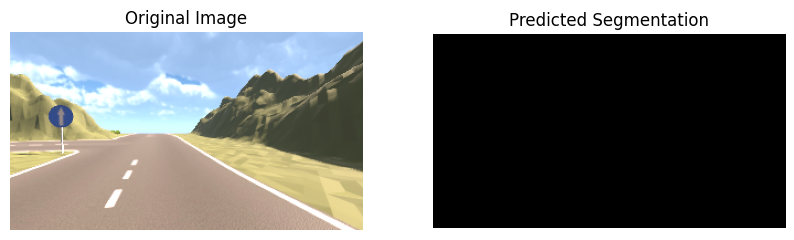

In [2]:
model.load_state_dict(torch.load('8_class_model.pth'))

# Predict and show result
image_path = r'D:\Demo 1.2\Unet\data\output_raw\0028.png'
predict_and_show(model, image_path, transform, device='cuda' if torch.cuda.is_available() else 'cpu')